# Netflix Data Analysis

In [1]:
import pandas as pd

df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
#Basic overview
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
# Missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [3]:
#duplicates 
df.duplicated().sum()
df = df.drop_duplicates()

In [4]:
# handling missing values 
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df = df.dropna(subset=['date_added', 'rating', 'duration'])

In [5]:
#date conversion
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

In [6]:
#final check
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      88
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

## Summary
- Loaded and cleaned the Netflix dataset by handling missing values  
- Converted date_added to datetime format  
The dataset is now ready for further analysis.

In [7]:
#Extract year and month from date_added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

df[['date_added', 'year_added', 'month_added']].head()

,date_added,year_added,month_added
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


In [8]:
#Extract numeric value from duration column
df['duration_int'] = df['duration'].str.extract(r'(\d+)')
df['duration_int'] = df['duration_int'].astype(float)     
df[['duration', 'duration_int']].head()

,duration,duration_int
0,90 min,90.0
1,2 Seasons,2.0
2,1 Season,1.0
3,1 Season,1.0
4,2 Seasons,2.0


In [9]:
#number of Movies vs TV Shows
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

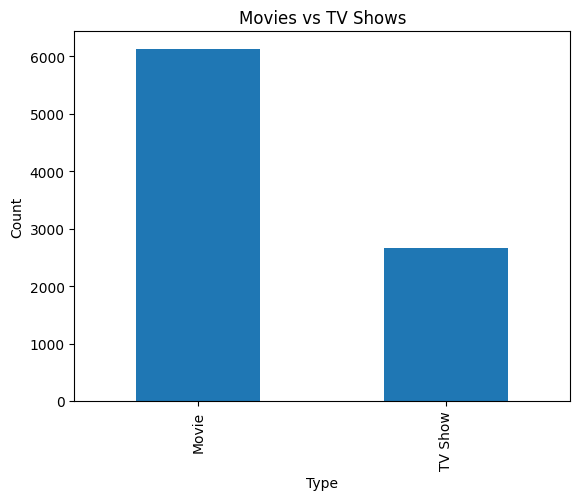

In [10]:
import matplotlib.pyplot as plt
# Plot bar chart
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

### Insight:
- Movies are significantly higher in number than TV Shows
- This suggests Netflix currently focuses more on movie-based content
- However, TV Shows still form a substantial portion of the catalog

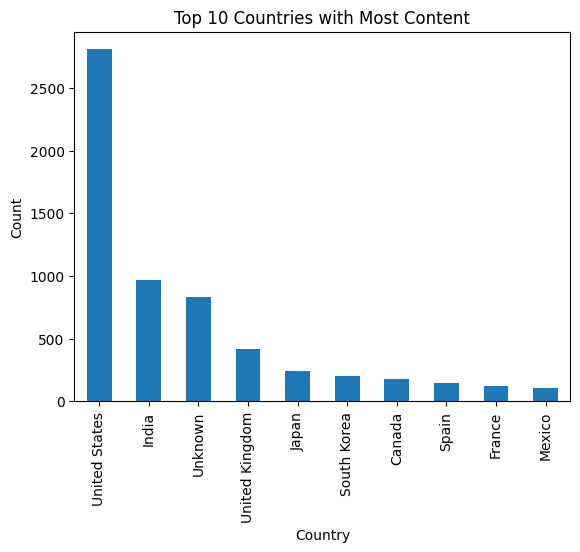

In [11]:
#Top 10 countries
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='bar')

plt.title("Top 10 Countries with Most Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

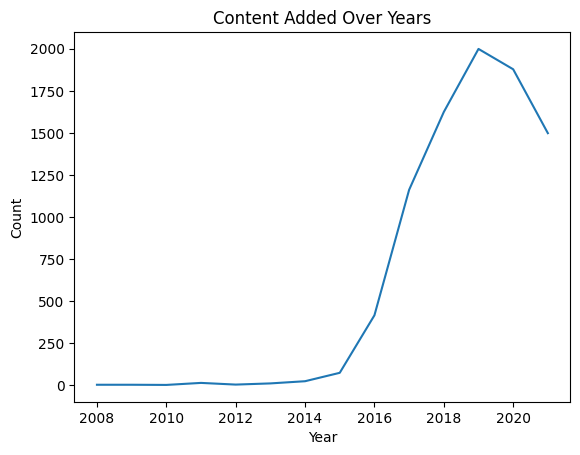

In [12]:
#Content added per year
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

### Insight:
- Content addition increased rapidly after 2015
- Peak observed around 2019–2020
- Slight decline observed in recent years

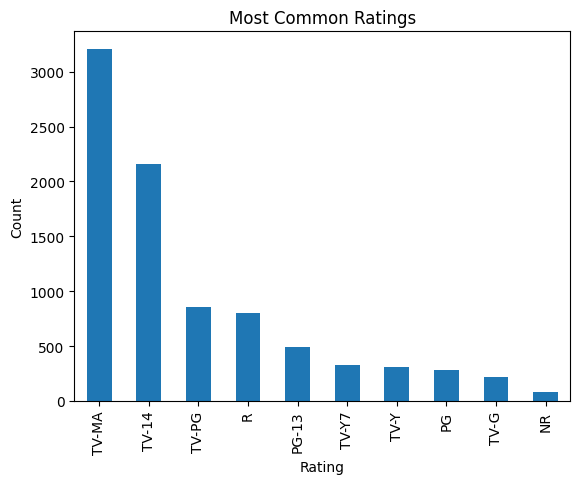

In [13]:
#Rating distribution
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Most Common Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Insight:
- TV-MA and TV-14 are the most common ratings
- Netflix content is primarily targeted towards mature audiences
- There is less content available for younger audiences

## Summary

- Extracted date-based features (year, month)
- Cleaned duration column into numeric format
- Analyzed content type distribution
- Identified top countries and ratings
- Visualized trends using bar and line charts

##  Machine Learning

In [14]:
#target variable distribution
df['type'].value_counts()
#Selecting features for ML
df_ml = df[['type', 'country', 'rating', 'release_year']]

df_ml.head()

,type,country,rating,release_year
0,Movie,United States,PG-13,2020
1,TV Show,South Africa,TV-MA,2021
2,TV Show,Unknown,TV-MA,2021
3,TV Show,Unknown,TV-MA,2021
4,TV Show,India,TV-MA,2021


In [15]:
#Check missing values
df_ml.isnull().sum()

type            0
country         0
rating          0
release_year    0
dtype: int64

In [16]:
#Convert target variable to numbers
df_ml['type'] = df_ml['type'].map({'Movie': 0, 'TV Show': 1})
df_ml.head()

,type,country,rating,release_year
0,0,United States,PG-13,2020
1,1,South Africa,TV-MA,2021
2,1,Unknown,TV-MA,2021
3,1,Unknown,TV-MA,2021
4,1,India,TV-MA,2021


In [17]:
#One hot encoding for categorical features
df_ml = pd.get_dummies(df_ml, columns=['country', 'rating'])
df_ml.head()

,type,release_year,"country_, France, Algeria","country_, South Korea",country_Argentina,"country_Argentina, Brazil, France, Poland, Germany, Denmark","country_Argentina, Chile","country_Argentina, Chile, Peru","country_Argentina, France","country_Argentina, France, United States, Germany, Qatar",...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,0,2020,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,1,2021,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,1,2021,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,1,2021,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,1,2021,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [18]:
from sklearn.model_selection import train_test_split
#Features (X) and Target (y)
X = df_ml.drop('type', axis=1)
y = df_ml['type']

#Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((7032, 764), (1758, 764))

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7337883959044369


## summary

- Logistic Regression model was used for classification
- An initial model achieved very high accuracy (~99%), indicating the presence of a strongly influencing feature
- Further analysis revealed that the duration feature was dominating the predictions
- After removing this feature, the model achieved a more realistic accuracy of ~73%
- Feature scaling was applied to improve model convergence
- The final model provides a balanced and reliable prediction of content type

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.90      0.83      1227
           1       0.60      0.34      0.44       531

    accuracy                           0.73      1758
   macro avg       0.68      0.62      0.63      1758
weighted avg       0.71      0.73      0.71      1758



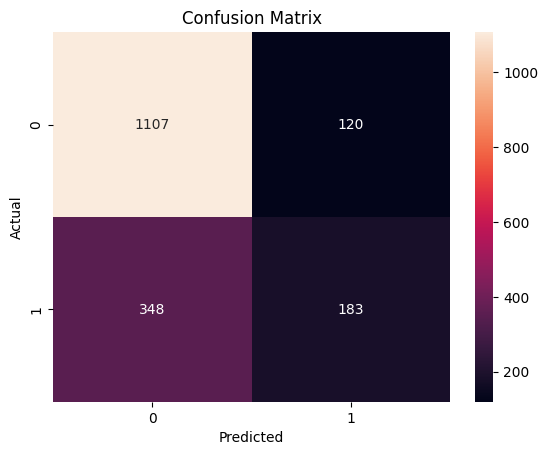

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
from sklearn.metrics import roc_auc_score

print("ROC AUC:", roc_auc_score(y_test, y_pred))

ROC AUC: 0.6234166286795685


- ROC AUC score of ~0.63 indicates moderate class separation capability of the model

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.754835039817975


### Model Comparison

- Logistic Regression achieved ~73% accuracy
- Random Forest improved performance to ~75%
- This indicates that Random Forest captures more complex patterns in the data

In [24]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

release_year           0.308702
rating_R               0.049728
country_South Korea    0.046660
country_India          0.041307
country_Japan          0.036427
rating_PG-13           0.028074
country_Unknown        0.026773
country_Taiwan         0.025842
rating_TV-Y7           0.025131
rating_TV-14           0.024876
dtype: float64


### Feature Importance Insight

- The most important feature is release_year, suggesting that temporal patterns influence content type
- Although release_year does not directly determine whether content is a Movie or TV Show, it helps the model capture trends over time
- Ratings also play a key role in distinguishing between Movies and TV Shows
- Country-based features contribute to the prediction, highlighting regional content patterns
- The model relies on both temporal and categorical patterns rather than direct relationships